## subplots

לפעמים רוצים כמה גרפים **נפרדים** באותו figure, לא כמה עקומות על אותו ציר. לכך נועד `plt.subplots(nrows, ncols)`: הוא מחזיר `fig` יחיד, ומערך `axs` של צירים בגודל `nrows × ncols`.

```python
fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
axs[0].plot(...)   # הציר הראשון
axs[1].plot(...)   # הציר השני
```

```{note}
כאשר `nrows=1` (או `ncols=1`), `axs` הוא מערך **חד-ממדי** — גישה עם `axs[i]`. כאשר גם `nrows>1` וגם `ncols>1`, `axs` הוא מערך **דו-ממדי** — גישה עם `axs[row, col]`, בדיוק כמו אינדוקס מערך NumPy רגיל.
```

### דוגמה: פאנל נפרד לכל זווית שיגור

במקום לצייר את שלוש הזוויות על אותו גרף (כמו בסעיף 8.5), הפעם ניתן לכל זווית ציר משלה, עם `sharey=True` כדי שיהיה קל להשוות גבהים.

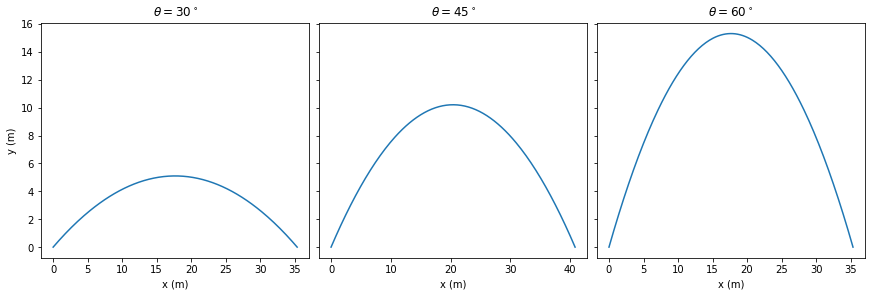

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g, v0 = 9.8, 20.0          # m/s^2, m/s
angles_deg = [30, 45, 60]

fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True, constrained_layout=True)
for ax, angle in zip(axs, angles_deg):
    theta = np.radians(angle)
    t_flight = 2 * v0 * np.sin(theta) / g
    t = np.linspace(0, t_flight, 200)
    x = v0 * np.cos(theta) * t
    y = v0 * np.sin(theta) * t - 0.5 * g * t**2
    ax.plot(x, y)
    ax.set_title(fr"$\theta={angle}^\circ$")
    ax.set_xlabel("x (m)")

axs[0].set_ylabel("y (m)")
plt.show()

### נסו בעצמכם

שנו את הפריסה לרשת של 3 שורות על עמודה אחת (`plt.subplots(3, 1, ...)`), עם `sharex=True` במקום `sharey=True`.

In [2]:
# fig, axs = plt.subplots(3, 1, ...)
# ...

`````{admonition} פתרון
:class: dropdown, tip
```python
fig, axs = plt.subplots(3, 1, figsize=(5, 9), sharex=True, constrained_layout=True)
for ax, angle in zip(axs, angles_deg):
    theta = np.radians(angle)
    t_flight = 2 * v0 * np.sin(theta) / g
    t = np.linspace(0, t_flight, 200)
    x = v0 * np.cos(theta) * t
    y = v0 * np.sin(theta) * t - 0.5 * g * t**2
    ax.plot(x, y)
    ax.set_title(fr"$\theta={angle}^\circ$")
    ax.set_ylabel("y (m)")

axs[-1].set_xlabel("x (m)")
plt.show()
```
`````

### בדקו את עצמכם

In [3]:
from jupyterquiz import display_quiz

questions = [
    {
        "question": "כאשר קוראים <code>fig, axs = plt.subplots(2, 2)</code>, איך ניגשים לציר שבפינה השמאלית העליונה?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "axs[0, 0]", "correct": True, "feedback": "נכון — כש-nrows>1 וגם ncols>1, axs הוא מערך דו-ממדי."},
            {"answer": "axs[0]", "correct": False, "feedback": "לא — axs כאן דו-ממדי."},
            {"answer": "axs.first()", "correct": False, "feedback": "אין פונקציה כזו."},
            {"answer": "axs[0][1]", "correct": False, "feedback": "לא — זו הפינה הימנית העליונה (טור 1 בשורה 0), לא השמאלית."}
        ]
    }
]
display_quiz(questions)

<IPython.core.display.Javascript object>

### תרגול עצמי

צרו רשת `2×2` של subplots (4 צירים). ב-3 מהם ציירו את מסלולי שלוש הזוויות (30°, 45°, 60°) בנפרד, ובציר הרביעי ציירו את כולן יחד (כמו בסעיף 8.5).

In [4]:
# fig, axs = plt.subplots(2, 2, ...)
# ...

`````{admonition} פתרון
:class: dropdown, tip
```python
fig, axs = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True)
flat_axs = axs.flatten()

for ax, angle in zip(flat_axs[:3], angles_deg):
    theta = np.radians(angle)
    t_flight = 2 * v0 * np.sin(theta) / g
    t = np.linspace(0, t_flight, 200)
    x = v0 * np.cos(theta) * t
    y = v0 * np.sin(theta) * t - 0.5 * g * t**2
    ax.plot(x, y)
    ax.set_title(fr"$\theta={angle}^\circ$")

ax_all = flat_axs[3]
for angle in angles_deg:
    theta = np.radians(angle)
    t_flight = 2 * v0 * np.sin(theta) / g
    t = np.linspace(0, t_flight, 200)
    x = v0 * np.cos(theta) * t
    y = v0 * np.sin(theta) * t - 0.5 * g * t**2
    ax_all.plot(x, y, label=fr"$\theta={angle}^\circ$")
ax_all.set_title("הכול יחד")
ax_all.legend()

plt.show()
```
`````